In [1]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = pd.read_excel("E:\\mp\\new adidas.xlsx", usecols=['InvoiceDate', 'TotalSales'])


In [3]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'], format='%d-%m-%Y')
monthly_sales = data.groupby(pd.Grouper(key='InvoiceDate', freq='MS')).sum()
monthly_sales.reset_index(inplace=True)


In [4]:
monthly_sales['Month'] = monthly_sales['InvoiceDate'].dt.strftime('%m-%Y')
monthly_sales = monthly_sales[['Month', 'TotalSales']]


In [5]:
monthly_sales.to_csv('monthly_sales.csv', index=False)

In [6]:
monthly_sales = pd.read_csv('monthly_sales.csv')

In [7]:
print(monthly_sales)

      Month  TotalSales
0   01-2020  16253746.0
1   02-2020  14997988.0
2   03-2020  17660577.0
3   04-2020  24607006.0
4   05-2020  16918014.0
5   06-2020   8829819.0
6   07-2020  17146013.0
7   08-2020  19877980.0
8   09-2020  18304436.0
9   10-2020  10836269.0
10  11-2020   8622300.0
11  12-2020   8026527.0
12  01-2021  55225396.0
13  02-2021  46102165.0
14  03-2021  39148532.0
15  04-2021  47732964.0
16  05-2021  63589681.0
17  06-2021  65917553.0
18  07-2021  78334681.0
19  08-2021  72288221.0
20  09-2021  59357023.0
21  10-2021  53074764.0
22  11-2021  59235040.0
23  12-2021  77815430.0


In [8]:
model = Prophet()



In [9]:
monthly_sales = monthly_sales.rename(columns={'Month': 'ds', 'TotalSales': 'y'})


In [10]:
model.fit(monthly_sales)


c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\forecaster.py:1133: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  self.history_dates = pd.to_datetime(pd.Series(history['ds'].unique(), name='ds')).sort_values()
c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\forecaster.py:287: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['ds'] = pd.to_datetime(df['ds'])
11:47:30 - cmdstanpy - INFO - Chain [1] start processing
11:47:30 - cmdstanpy - INFO - Chain [1] done processing


In [11]:
future_dates = model.make_future_dataframe(periods=3, freq='M')


c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [12]:
forecast = model.predict(future_dates)


c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',


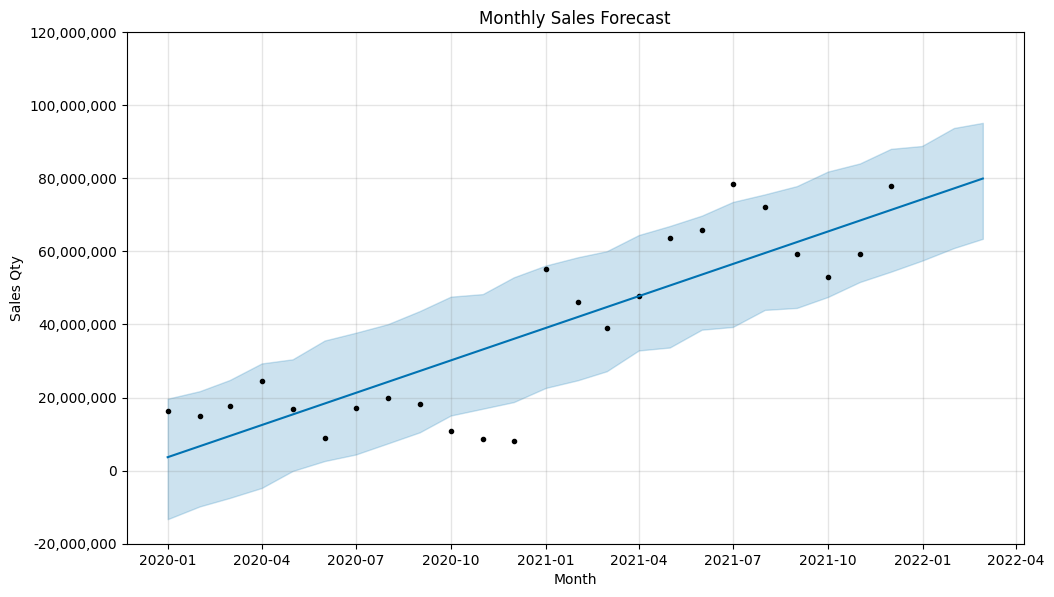

In [13]:
fig = model.plot(forecast)
plt.xlabel('Month')
plt.ylabel('Sales Qty')
plt.title('Monthly Sales Forecast')
ymin, ymax = plt.gca().get_ylim()

# Set the y-axis limits to display actual sales values
plt.yticks(plt.yticks()[0], ['{:,.0f}'.format(x) for x in plt.yticks()[0]])

# Show the plot
plt.grid(True)
plt.show()